# Exploration des annonces Airbnb à Montréal

**Objectif :** comprendre les données avant de modéliser le prix par nuit d'un logement Airbnb à Montréal.

**Source :** [Inside Airbnb](https://insideairbnb.com/get-the-data/), instantané du 15 juin 2026 (licence CC BY 4.0),
et les stations de métro issues des données GTFS de la STM.

**Plan :**
1. Les données brutes
2. Les valeurs manquantes
3. Prix et types de logement
4. La distribution du prix
5. Le prix par quartier
6. Capacité et distance au métro
7. La durée minimale de séjour
8. Carte des prix
9. Corrélations
10. Conclusion

In [1]:

import folium
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.clean import COLUMNS, parse_price
from src.config import LISTINGS_RAW, METRO_STATIONS, ROOT
from src.train import load_dataset

sns.set_theme(style="whitegrid")
FIGURES = ROOT / "figures"
FIGURES.mkdir(exist_ok=True)

## 1. Les données brutes

Le fichier `listings.csv.gz` contient une ligne par annonce et 90 colonnes. Je n'affiche que les
colonnes que je garde pour la suite, définies dans `src/clean.py`.

In [2]:
raw = pd.read_csv(LISTINGS_RAW)
print(raw.shape)
raw[COLUMNS].head()

(10656, 90)


,id,price,room_type,neighbourhood_cleansed,latitude,longitude,accommodates,bedrooms,beds,bathrooms_text,amenities,minimum_nights
0,29059,$245.00,Entire home/apt,Ville-Marie,45.51939,-73.56482,4,1.0,2.0,1 bath,"[""Shared backyard \u2013 Fully fenced"", ""Mosqu...",1.0
1,29061,$475.40,Entire home/apt,Ville-Marie,45.51929,-73.56493,4,2.0,2.0,1 bath,"[""Mosquito net"", ""Fire extinguisher"", ""Microwa...",1.0
2,38118,$25.98,Private room,Ville-Marie,45.52699,-73.55840,1,3.0,4.0,1 shared bath,"[""Heating"", ""Washer"", ""Free street parking"", ""...",31.0
3,50479,$268.00,Entire home/apt,Rosemont-La Petite-Patrie,45.54157,-73.60737,3,2.0,NaN,1 bath,"[""Bathtub"", ""Oven"", ""Smoke alarm"", ""Iron"", ""Se...",3.0
4,66247,$287.58,Entire home/apt,Ville-Marie,45.50584,-73.55602,4,1.0,1.0,1 bath,"[""Heating"", ""Washer"", ""Microwave"", ""Iron"", ""St...",1.0


Le fichier contient **10 656 annonces**. Quelques points à noter :
- le prix est stocké comme du texte (`"$245.00"`) : il faudra le convertir en nombre ;
- `amenities` (équipements) est une liste écrite sous forme de texte ;
- `bathrooms_text` mélange un nombre et une description (`"1.5 shared baths"`).

J'ai volontairement écarté les colonnes calculées à partir du prix, comme `estimated_revenue_l365d`
(revenu estimé). Les garder permettrait au modèle de « tricher » : c'est une **fuite de données**.

## 2. Les valeurs manquantes

In [3]:
raw[COLUMNS].isna().mean().sort_values(ascending=False).round(3)

beds                      0.181
bedrooms                  0.171
price                     0.110
bathrooms_text            0.001
minimum_nights            0.000
neighbourhood_cleansed    0.000
id                        0.000
room_type                 0.000
accommodates              0.000
longitude                 0.000
latitude                  0.000
amenities                 0.000
dtype: float64

- **11 % des annonces n'ont pas de prix.** Elles sont inutilisables pour apprendre à prédire le prix : je les retire.
- `bedrooms` (17 %) et `beds` (18 %) ont beaucoup de valeurs manquantes. Je ne supprime pas ces lignes,
  sinon je perdrais près d'une annonce sur cinq. Les trous seront remplacés par la **médiane**, à l'intérieur
  du pipeline de modélisation. Faire ce calcul uniquement sur les données d'entraînement évite
  qu'une information du jeu de test « fuite » dans le modèle.
- Pour les salles de bain, j'utilise `bathrooms_text` (0,1 % de valeurs manquantes) plutôt que la colonne
  `bathrooms` (21 %).

## 3. Prix et types de logement

In [4]:
raw_prices = parse_price(raw["price"])
print(raw_prices.describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).round(1))
raw["room_type"].value_counts()

count    9485.0
mean      222.5
std       288.6
min         3.9
1%         18.1
5%         32.7
50%       162.3
95%       556.9
99%      1233.1
max      6935.0
Name: price, dtype: float64


room_type
Entire home/apt    8728
Private room       1845
Hotel room           53
Shared room          30
Name: count, dtype: int64

**Prix :** la médiane est de 162 $ la nuit, mais les extrêmes sont étonnants : un minimum de 3,88 $ et un
maximum de 6 935 $. Seulement 1 % des annonces sont sous 18 $ et 1 % au-dessus de 1 233 $. Ce sont
probablement des erreurs de saisie ou des cas très particuliers (prix symboliques, villas de luxe).
**Je garde les annonces entre 20 $ et 1 000 $.**

**Types de logement :** 82 % de logements entiers, 17 % de chambres privées, et moins de 1 % de chambres
d'hôtel (53) et de chambres partagées (30). Ces deux dernières catégories sont trop rares pour que
le modèle apprenne quelque chose de fiable : **je garde seulement les logements entiers et les chambres privées.**

## 4. La distribution du prix

Après nettoyage, je compare la distribution du prix à celle de son logarithme.

9165 annonces gardées sur 10656


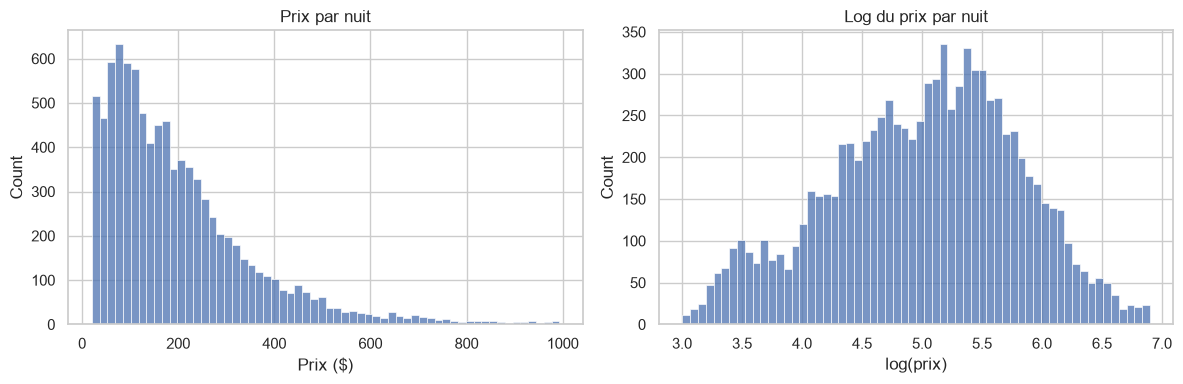

In [5]:
df = load_dataset()
print(f"{len(df)} annonces gardées sur {len(raw)}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["price"], bins=60, ax=axes[0])
axes[0].set(title="Prix par nuit", xlabel="Prix ($)")
sns.histplot(np.log(df["price"]), bins=60, ax=axes[1])
axes[1].set(title="Log du prix par nuit", xlabel="log(prix)")
fig.tight_layout()
fig.savefig(FIGURES / "price_distribution.png", dpi=120)

Il reste **9 165 annonces sur 10 656** (86 %).

La distribution du prix est très **asymétrique** : la plupart des logements coûtent entre 50 $ et 300 $,
mais une longue « queue » monte jusqu'à 1 000 $. La moyenne (200 $) est d'ailleurs nettement au-dessus
de la médiane (162 $).

Le **logarithme du prix** a une forme beaucoup plus symétrique, proche d'une cloche : son coefficient
d'asymétrie passe de 1,67 à -0,23. C'est pour ça que le modèle apprendra à prédire `log(prix)` : les
logements très chers pèsent moins lourd dans l'apprentissage, et une erreur de 10 % compte autant sur un
logement à 50 $ que sur un logement à 500 $.

## 5. Le prix par quartier

Je regarde le prix médian des 15 quartiers qui ont le plus d'annonces. Je prends la **médiane**
plutôt que la moyenne, parce qu'elle est moins sensible aux quelques logements très chers.

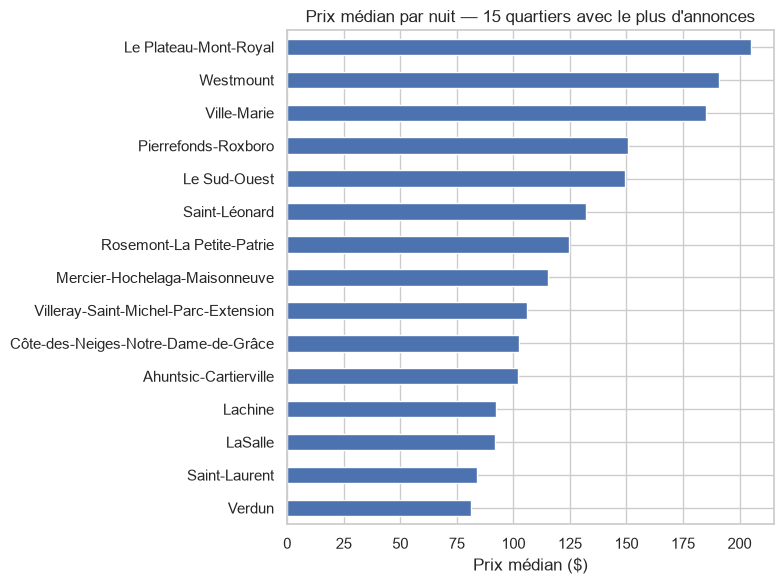

In [6]:
top = df["neighbourhood_cleansed"].value_counts().head(15).index
by_hood = (
    df[df["neighbourhood_cleansed"].isin(top)]
    .groupby("neighbourhood_cleansed")["price"]
    .median()
    .sort_values()
)
fig, ax = plt.subplots(figsize=(8, 6))
by_hood.plot.barh(ax=ax)
ax.set(title="Prix médian par nuit — 15 quartiers avec le plus d'annonces", xlabel="Prix médian ($)", ylabel="")
fig.tight_layout()
fig.savefig(FIGURES / "price_by_neighbourhood.png", dpi=120)

- Les quartiers centraux et touristiques sont les plus chers : **Le Plateau-Mont-Royal (205 $)**,
  **Westmount (191 $)** et **Ville-Marie (185 $, le centre-ville)**.
- À l'opposé, Verdun (81 $), Saint-Laurent (84 $), LaSalle et Lachine (92 $) sont plus de deux fois moins chers.
- Les annonces sont très concentrées : Ville-Marie en compte à lui seul 3 557, soit près de **40 %**
  des annonces, et le Plateau 1 841.

L'emplacement compte clairement. Je vais le représenter de plusieurs façons dans le modèle : le quartier,
les coordonnées GPS, la distance au centre-ville et la distance au métro.

## 6. Capacité et distance au métro

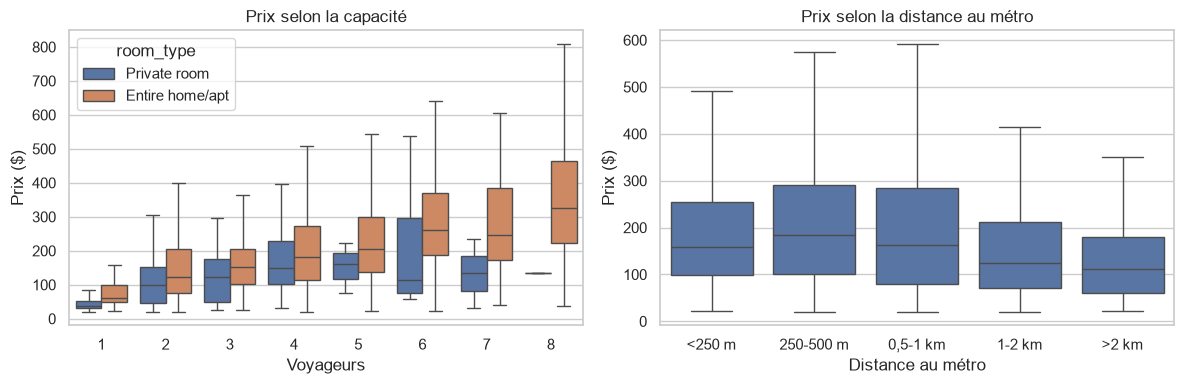

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df[df["accommodates"] <= 8], x="accommodates", y="price", hue="room_type", showfliers=False, ax=axes[0])
axes[0].set(title="Prix selon la capacité", xlabel="Voyageurs", ylabel="Prix ($)")
metro_bins = pd.cut(df["dist_metro_km"], [0, 0.25, 0.5, 1, 2, 50], labels=["<250 m", "250-500 m", "0,5-1 km", "1-2 km", ">2 km"])
sns.boxplot(x=metro_bins, y=df["price"], showfliers=False, ax=axes[1])
axes[1].set(title="Prix selon la distance au métro", xlabel="Distance au métro", ylabel="Prix ($)")
fig.tight_layout()
fig.savefig(FIGURES / "price_vs_capacity_metro.png", dpi=120)

**Capacité :** le prix médian monte presque régulièrement avec le nombre de voyageurs, de 39 $ pour
1 personne à 183 $ pour 4 et 324 $ pour 8. À capacité égale, un logement entier coûte bien plus cher
qu'une chambre privée (médianes de 183 $ contre 61 $).

**Distance au métro :** 82 % des annonces sont à moins d'un kilomètre d'une station. L'effet n'est pas
linéaire :
- jusqu'à 1 km, le prix varie peu (entre 158 $ et 185 $ de médiane) ;
- au-delà, il baisse nettement : 124 $ entre 1 et 2 km, 112 $ au-delà de 2 km.

La distance au métro semble surtout distinguer le centre bien desservi des secteurs périphériques.
Un modèle à base d'arbres (Random Forest) capte ce genre d'effet « en escalier » mieux qu'un modèle linéaire.

## 7. La durée minimale de séjour

En explorant les colonnes, j'ai remarqué que `minimum_nights` (le nombre minimum de nuits imposé par
l'hôte) prend très souvent la valeur 31. Je compare les deux groupes.

minimum_nights
31.0    3641
1.0     3302
2.0     1036
32.0     698
3.0      164
60.0      56
Name: count, dtype: int64
                  size  median
31 nuits et plus              
False             4611  245.36
True              4554   89.93


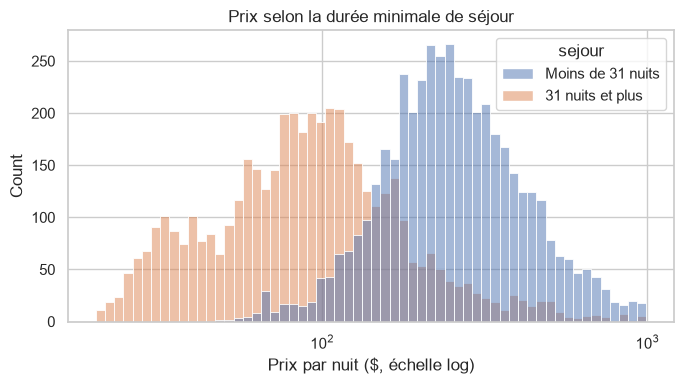

In [8]:
print(df["minimum_nights"].value_counts().head(6))
monthly = df["minimum_nights"] >= 31
print(df.groupby(monthly.rename("31 nuits et plus"))["price"].agg(["size", "median"]))

fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(data=df.assign(sejour=np.where(monthly, "31 nuits et plus", "Moins de 31 nuits")), x="price", hue="sejour", bins=60, log_scale=True, ax=ax)
ax.set(title="Prix selon la durée minimale de séjour", xlabel="Prix par nuit ($, échelle log)")
fig.tight_layout()
fig.savefig(FIGURES / "minimum_nights.png", dpi=120)

C'est la découverte la plus marquante de l'exploration : **les annonces se partagent en deux marchés
presque de même taille.**

| | Annonces | Prix médian |
|---|---:|---:|
| Moins de 31 nuits minimum (location touristique) | 4 611 | **245 $** |
| 31 nuits minimum ou plus (location au mois) | 4 554 | **90 $** |

Le prix par nuit est presque **3 fois plus bas** pour les locations au mois. L'histogramme montre deux
« bosses » bien séparées.

**Hypothèse (à vérifier) :** la réglementation québécoise sur l'hébergement touristique de courte durée
pourrait pousser beaucoup d'hôtes à n'accepter que des séjours d'au moins 31 nuits.

Cette variable sera probablement déterminante pour le modèle.

## 8. Carte des prix

Chaque point est une annonce, colorée selon le logarithme de son prix (jaune = cher, violet = bon marché).
Les triangles rouges sont les stations de métro.

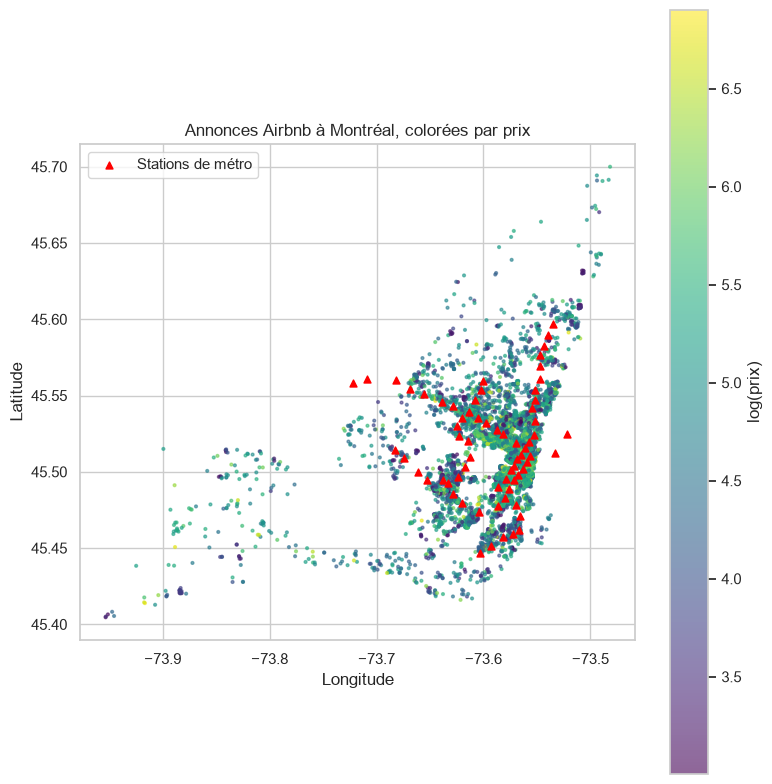

In [9]:
stations = pd.read_csv(METRO_STATIONS)
fig, ax = plt.subplots(figsize=(8, 8))
points = ax.scatter(df["longitude"], df["latitude"], c=np.log(df["price"]), cmap="viridis", s=4, alpha=0.6)
ax.scatter(stations["lon"], stations["lat"], marker="^", color="red", s=25, label="Stations de métro")
fig.colorbar(points, ax=ax, label="log(prix)")
ax.set(title="Annonces Airbnb à Montréal, colorées par prix", xlabel="Longitude", ylabel="Latitude")
ax.legend()
ax.set_aspect(1 / np.cos(np.radians(45.5)))
fig.tight_layout()
fig.savefig(FIGURES / "price_map.png", dpi=120)

- Les annonces sont très concentrées dans le centre de l'île, le long des lignes de métro.
- Les points les plus chers (jaunes) se regroupent autour du centre-ville et du Plateau.
- L'ouest de l'île, loin du métro, compte peu d'annonces, avec des prix plutôt bas ou moyens.

### Carte interactive

Un échantillon de 1 500 annonces : en **rouge** celles au-dessus du prix médian, en **bleu** celles en dessous.
Clique sur un point pour voir son prix et son quartier.

*Cette carte ne s'affiche pas sur GitHub : c'est pour ça que j'ai aussi enregistré la carte statique ci-dessus.*

In [10]:
sample = df.sample(1500, random_state=42)
carte = folium.Map(location=[45.51, -73.58], zoom_start=12, tiles="cartodbpositron")
for _, row in sample.iterrows():
    folium.CircleMarker(
        [row["latitude"], row["longitude"]],
        radius=3,
        color="crimson" if row["price"] > df["price"].median() else "steelblue",
        fill=True,
        popup=f"{row['price']:.0f} $ — {row['neighbourhood_cleansed']}",
    ).add_to(carte)
carte

C:\Users\sidim\.conda\envs\airbnb-mtl\Lib\site-packages\folium\raster_layers.py:130: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tiles = tiles.build_url(fill_subdomain=False, scale_factor="{r}")  # type: ignore


## 9. Corrélations avec le prix

J'utilise la corrélation de **Spearman**, qui compare les rangs plutôt que les valeurs brutes. Elle est moins
sensible aux valeurs extrêmes et détecte aussi les relations non linéaires, du moment qu'elles vont
toujours dans le même sens.

In [11]:
numeric = ["price", "accommodates", "bedrooms", "beds", "bathrooms", "dist_metro_km", "dist_downtown_km", "n_amenities", "minimum_nights"]
df[numeric].corr(method="spearman")["price"].drop("price").sort_values()

minimum_nights     -0.653990
dist_downtown_km   -0.291440
dist_metro_km      -0.114430
bathrooms           0.202177
n_amenities         0.343390
bedrooms            0.344821
beds                0.464576
accommodates        0.577458
Name: price, dtype: float64

- **Le nombre minimum de nuits** est la variable la plus liée au prix (-0,65) : ça confirme la section 7.
- La capacité (`accommodates`, +0,58) et le nombre de lits (+0,46) viennent ensuite : plus un logement
  accueille de monde, plus il est cher.
- Les chambres (+0,34) et le nombre d'équipements (+0,34) comptent aussi.
- S'éloigner du centre-ville fait baisser le prix (-0,29). La distance au métro a un lien plus faible (-0,11),
  ce qui colle avec l'effet « en escalier » vu à la section 6.

Attention : une corrélation ne prouve pas une causalité. Par exemple, les logements avec plus d'équipements
sont peut-être simplement plus grands.

## 10. Conclusion

- Après nettoyage, il reste **9 165 annonces** exploitables sur 10 656.
- Le prix est très asymétrique : je modéliserai **son logarithme**.
- Trois familles de variables semblent déterminantes :
  1. **la durée minimale de séjour**, qui sépare deux marchés (90 $ contre 245 $ la nuit) ;
  2. **la taille du logement** (voyageurs, chambres, lits, type de logement) ;
  3. **l'emplacement** (quartier, distance au centre-ville et au métro).
- Certaines relations ne sont pas linéaires (distance au métro) : des modèles à base d'arbres devraient
  mieux s'en sortir qu'une régression linéaire.

**Prochaine étape :** comparer plusieurs modèles dans le notebook `02_modelisation.ipynb`.